## Steps   

-   Data Cleaning
-   EDA
-   Feature Engineering


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4f}'.format
%matplotlib inline

In [2]:
df = pd.read_csv(r'C:\Python\Udemy\EDA\Google playstore EDA\google_playstore.csv' ,encoding='latin1')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1000,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9000,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite  FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7000,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5000,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3000,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df_copy = df.copy()

In [4]:
df_copy.shape

(10841, 13)

In [5]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
df_copy.describe()

,Rating
count,9367.0000
mean,4.1933
std,0.5374
min,1.0000
25%,4.0000
50%,4.3000
75%,4.5000
max,19.0000


In [7]:
df_copy.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [8]:
df_copy.duplicated().sum()

np.int64(483)

In [9]:
df_copy.duplicated('App').sum()

np.int64(1181)

In [10]:
duplicates = df_copy[df_copy.duplicated(keep=False)].sort_values('App')
duplicates


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0000,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0000,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
2543,1800 Contacts - Lens Store,MEDICAL,4.7000,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2322,1800 Contacts - Lens Store,MEDICAL,4.7000,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4000,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3063,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4000,133833,34M,"10,000,000+",Free,0,Everyone 10+,Sports,"July 25, 2018",6.17.2,4.4 and up
3055,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4000,133833,34M,"10,000,000+",Free,0,Everyone 10+,Sports,"July 25, 2018",6.17.2,4.4 and up
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2000,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3202,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2000,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device


## Basic Observation 
- Missing Valuse Found in Rating , Type , Content Rating , Current Ver , Android Ver
- data have duplicate rows (483 full duplicate)

## DATA CLEANING

In [11]:
# 1. Remove duplicates
df_copy = df_copy.drop_duplicates()
df_copy.Size
df_copy

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1000,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9000,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite  FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7000,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5000,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3000,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5000,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0000,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5000,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


now to handle the cases which have only the App column value same, we will keep the latest record and drop the rest occurence

In [12]:
# for that converting the 'Last Updated' column in proper date time format

print(df_copy['Last Updated'].isnull().sum())

df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'] , format='%B %d, %Y' , errors='coerce')

0


In [13]:
print(df_copy['Last Updated'].dtype)
print(df_copy['Last Updated'].min())

datetime64[ns]
2010-05-21 00:00:00


In [14]:
# to check unparsed 
nat_rows = df_copy[df_copy['Last Updated'].isna()]
print(f"Failed to parse: {len(nat_rows)} row(s)")
print(nat_rows[['App', 'Last Updated']])

#dropping uparsed row
df_copy = df_copy.dropna(subset=['Last Updated'])

Failed to parse: 1 row(s)
                                           App Last Updated
10472  Life Made WI-Fi Touchscreen Photo Frame          NaT


In [15]:
print(df_copy['Last Updated'].dtype)  
print(df_copy['Last Updated'].min())
print(df_copy['Last Updated'].max())  


datetime64[ns]
2010-05-21 00:00:00
2018-08-08 00:00:00


In [16]:
df_copy.shape

(10357, 13)

In [17]:
# converting reviews to int

df_copy['Reviews']=df_copy['Reviews'].astype(int)

In [18]:
df_app=df_copy[df_copy.duplicated('App', keep=False)].sort_values(['App','Last Updated','Reviews'] , ascending=False)
df_copy = df_copy.sort_values(['App','Last Updated','Reviews'] , ascending=False).drop_duplicates('App',keep = 'first')
df_copy

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3859,ÖBB Scotty,MAPS_AND_NAVIGATION,4.2000,12572,24M,"1,000,000+",Free,0,Everyone,Maps & Navigation,2018-02-19,5.4 (30),4.0 and up
9828,Égalité et Réconciliation,NEWS_AND_MAGAZINES,4.9000,58,3.8M,500+,Paid,$2.99,Everyone,News & Magazines,2018-05-26,1.1.1,5.0 and up
9819,¿Es Vegan?,FOOD_AND_DRINK,4.6000,438,1.7M,"10,000+",Free,0,Everyone,Food & Drink,2017-08-01,2.2.3,3.0 and up
5844,¡Ay Metro!,GAME,3.8000,489,36M,"10,000+",Free,0,Everyone 10+,Arcade,2015-03-17,1.0.3.1,4.0 and up
5832,¡Ay Caramba!,FAMILY,NaN,0,549k,1+,Paid,$1.99,Everyone,Education,2014-06-13,1.2,3.0 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4636,/u/app,COMMUNICATION,4.7000,573,53M,"10,000+",Free,0,Mature 17+,Communication,2018-07-03,4.2.4,4.1 and up
4541,.R,TOOLS,4.5000,259,203k,"10,000+",Free,0,Everyone,Tools,2014-09-16,1.1.06,1.5 and up
8532,+Download 4 Instagram Twitter,SOCIAL,4.5000,40467,22M,"1,000,000+",Free,0,Everyone,Social,2018-08-02,5.03,4.1 and up
324,#NAME?,COMICS,3.5000,115,9.1M,"10,000+",Free,0,Mature 17+,Comics,2018-07-13,5.0.12,5.0 and up


In [19]:
#  Handling missing values

df_copy.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [20]:
#1 Rating
# Rating should not br grater than 5.0

df_copy1 = df_copy[df_copy['Rating'] > 5]
df_copy1

#no value greater than 5
# now we will replace nulls with mean

print(f"Mean:   {df_copy['Rating'].mean():.3f}")
print(f"Median: {df_copy['Rating'].median():.3f}")
print(f"Mode:   {df_copy['Rating'].mode()[0]:.3f}")
print(f"Skewness: {df_copy['Rating'].skew():.3f}")

#left skew replace nulls with median
df_copy['Rating'] = df_copy['Rating'].fillna(df['Rating'].median())
df_copy.isnull().sum()

Mean:   4.173
Median: 4.300
Mode:   4.300
Skewness: -1.745


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       2
dtype: int64

In [21]:
#2 type
df_copy[df_copy['Type'].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9148,Command & Conquer: Rivals,FAMILY,4.3000,0,Varies with device,0,NaN,0,Everyone 10+,Strategy,2018-06-28,Varies with device,Varies with device


In [22]:
#as price is 0 replace null with Free
df_copy['Type'] = df_copy['Type'].fillna('Free')
df_copy['Type'].unique()

array(['Free', 'Paid'], dtype=object)

In [23]:
#3 Current ver
# replace null  by unkown

df_copy['Current Ver'] = df_copy['Current Ver'].fillna('Unknown')

#same for Android Ver
df_copy['Android Ver'] = df_copy['Android Ver'].fillna('Unknown')

df_copy.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [24]:
# cleaning columns Installs and Price
df_copy['Installs'].unique()

array(['1,000,000+', '500+', '10,000+', '1+', '10,000,000+', '100,000+',
       '100+', '50,000+', '1,000+', '50+', '500,000+', '50,000,000+',
       '5,000+', '100,000,000+', '10+', '5,000,000+', '500,000,000+',
       '5+', '0+', '1,000,000,000+', '0'], dtype=object)

In [25]:
df_copy['Price'].unique()

array(['0', '$2.99', '$1.99', '$1.20', '$0.99', '$4.29', '$399.99',
       '$4.99', '$4.49', '$3.99', '$10.00', '$1.49', '$154.99', '$1.96',
       '$5.49', '$19.40', '$5.99', '$12.99', '$2.50', '$19.99', '$2.56',
       '$9.99', '$1.04', '$2.90', '$1.00', '$2.49', '$79.99', '$8.99',
       '$16.99', '$1.97', '$3.49', '$17.99', '$6.99', '$6.49', '$2.95',
       '$4.59', '$4.85', '$7.49', '$10.99', '$4.84', '$1.76', '$7.99',
       '$29.99', '$4.60', '$3.02', '$14.99', '$39.99', '$1.70', '$15.99',
       '$24.99', '$9.00', '$1.59', '$8.49', '$1.61', '$89.99', '$74.99',
       '$15.46', '$1.26', '$400.00', '$299.99', '$379.99', '$18.99',
       '$37.99', '$389.99', '$25.99', '$3.88', '$13.99', '$2.00',
       '$30.99', '$394.99', '$11.99', '$4.77', '$3.61', '$200.00',
       '$28.99', '$46.99', '$3.28', '$3.95', '$14.00', '$2.59', '$4.80',
       '$109.99', '$1.75', '$3.90', '$1.50', '$1.29', '$2.60', '$19.90',
       '$5.00', '$3.04', '$33.99', '$3.08'], dtype=object)

In [26]:
chars_to_remove=['+',',','$']
cols_to_clean=['Installs','Price']
for item in chars_to_remove:
    for cols in cols_to_clean:
        df_copy[cols]=df_copy[cols].str.replace(item,'')

In [27]:
df_copy['Price'].unique()

array(['0', '2.99', '1.99', '1.20', '0.99', '4.29', '399.99', '4.99',
       '4.49', '3.99', '10.00', '1.49', '154.99', '1.96', '5.49', '19.40',
       '5.99', '12.99', '2.50', '19.99', '2.56', '9.99', '1.04', '2.90',
       '1.00', '2.49', '79.99', '8.99', '16.99', '1.97', '3.49', '17.99',
       '6.99', '6.49', '2.95', '4.59', '4.85', '7.49', '10.99', '4.84',
       '1.76', '7.99', '29.99', '4.60', '3.02', '14.99', '39.99', '1.70',
       '15.99', '24.99', '9.00', '1.59', '8.49', '1.61', '89.99', '74.99',
       '15.46', '1.26', '400.00', '299.99', '379.99', '18.99', '37.99',
       '389.99', '25.99', '3.88', '13.99', '2.00', '30.99', '394.99',
       '11.99', '4.77', '3.61', '200.00', '28.99', '46.99', '3.28',
       '3.95', '14.00', '2.59', '4.80', '109.99', '1.75', '3.90', '1.50',
       '1.29', '2.60', '19.90', '5.00', '3.04', '33.99', '3.08'],
      dtype=object)

In [28]:
df_copy['Installs']=df_copy['Installs'].astype('int')
df_copy['Price']=df_copy['Price'].astype('float')

In [29]:
# size column
# M - Mb (Megabytes) , K - kb(Kilobytes)
df_copy['Size'].unique()

array(['24M', '3.8M', '1.7M', '36M', '549k', '9.8M', 'Varies with device',
       '3.0M', '38M', '1.8M', '4.5M', '9.7M', '2.5M', '10.0M', '64M',
       '12M', '13M', '3.5M', '4.0M', '19M', '7.0M', '14M', '3.4M', '15M',
       '4.2M', '34M', '6.9M', '39M', '28M', '22M', '9.6M', '11M', '9.5M',
       '6.1M', '881k', '2.1M', '2.2M', '1.5M', '27M', '5.4M', '6.7M',
       '6.2M', '118k', '20M', '16M', '4.4M', '8.1M', '2.6M', '4.1M',
       '3.7M', '8.8M', '8.4M', '898k', '29M', '57M', '5.3M', '23M', '18M',
       '8.7M', '25M', '99M', '43M', '655k', '6.0M', '2.8M', '3.1M', '17M',
       '49M', '1.0M', '2.7M', '1.9M', '9.2M', '8.6M', '31M', '35M',
       '6.3M', '73M', '7.8M', '77M', '21M', '63M', '55M', '45M', '10M',
       '2.4M', '9.4M', '704k', '53M', '5.0M', '2.9M', '78M', '4.6M',
       '3.3M', '1.4M', '5.6M', '5.8M', '4.8M', '47M', '26M', '50M',
       '266k', '7.5M', '2.3M', '32M', '74M', '1.3M', '7.6M', '5.9M',
       '33k', '228k', '6.6M', '6.5M', '8.3M', '6.4M', '1.1M', '3.9M',
  

In [30]:
def convert_size(val):
    val = str(val).strip()
    if val == 'Varies with device':
        return None                      # can't know the size thats why set to NaN
    if val.endswith('M'):
        return float(val[:-1])           
    if val.endswith('k'):
        return float(val[:-1]) / 1024   
    return None                          

df_copy['Size_MB'] = df_copy['Size'].apply(convert_size)
df_copy['Size_MB'].unique()

array([2.40000000e+01, 3.80000000e+00, 1.70000000e+00, 3.60000000e+01,
       5.36132812e-01, 9.80000000e+00,            nan, 3.00000000e+00,
       3.80000000e+01, 1.80000000e+00, 4.50000000e+00, 9.70000000e+00,
       2.50000000e+00, 1.00000000e+01, 6.40000000e+01, 1.20000000e+01,
       1.30000000e+01, 3.50000000e+00, 4.00000000e+00, 1.90000000e+01,
       7.00000000e+00, 1.40000000e+01, 3.40000000e+00, 1.50000000e+01,
       4.20000000e+00, 3.40000000e+01, 6.90000000e+00, 3.90000000e+01,
       2.80000000e+01, 2.20000000e+01, 9.60000000e+00, 1.10000000e+01,
       9.50000000e+00, 6.10000000e+00, 8.60351562e-01, 2.10000000e+00,
       2.20000000e+00, 1.50000000e+00, 2.70000000e+01, 5.40000000e+00,
       6.70000000e+00, 6.20000000e+00, 1.15234375e-01, 2.00000000e+01,
       1.60000000e+01, 4.40000000e+00, 8.10000000e+00, 2.60000000e+00,
       4.10000000e+00, 3.70000000e+00, 8.80000000e+00, 8.40000000e+00,
       8.76953125e-01, 2.90000000e+01, 5.70000000e+01, 5.30000000e+00,
      

In [31]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 3859 to 8884
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          9659 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            9659 non-null   object        
 5   Installs        9659 non-null   int64         
 6   Type            9659 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9659 non-null   object        
 12  Android Ver     9659 non-null   object        
 13  Size_MB         8430 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(8)
memo

In [32]:
#finally extracting columns from date_time
df_copy['Day']=df_copy['Last Updated'].dt.day
df_copy['Month']=df_copy['Last Updated'].dt.month
df_copy['Month_Name']=df_copy['Last Updated'].dt.strftime('%B')
df_copy['Year']=df_copy['Last Updated'].dt.year

df_copy

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Day,Month,Month_Name,Year
3859,ÖBB Scotty,MAPS_AND_NAVIGATION,4.2000,12572,24M,1000000,Free,0.0000,Everyone,Maps & Navigation,2018-02-19,5.4 (30),4.0 and up,24.0000,19,2,February,2018
9828,Égalité et Réconciliation,NEWS_AND_MAGAZINES,4.9000,58,3.8M,500,Paid,2.9900,Everyone,News & Magazines,2018-05-26,1.1.1,5.0 and up,3.8000,26,5,May,2018
9819,¿Es Vegan?,FOOD_AND_DRINK,4.6000,438,1.7M,10000,Free,0.0000,Everyone,Food & Drink,2017-08-01,2.2.3,3.0 and up,1.7000,1,8,August,2017
5844,¡Ay Metro!,GAME,3.8000,489,36M,10000,Free,0.0000,Everyone 10+,Arcade,2015-03-17,1.0.3.1,4.0 and up,36.0000,17,3,March,2015
5832,¡Ay Caramba!,FAMILY,4.3000,0,549k,1,Paid,1.9900,Everyone,Education,2014-06-13,1.2,3.0 and up,0.5361,13,6,June,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4636,/u/app,COMMUNICATION,4.7000,573,53M,10000,Free,0.0000,Mature 17+,Communication,2018-07-03,4.2.4,4.1 and up,53.0000,3,7,July,2018
4541,.R,TOOLS,4.5000,259,203k,10000,Free,0.0000,Everyone,Tools,2014-09-16,1.1.06,1.5 and up,0.1982,16,9,September,2014
8532,+Download 4 Instagram Twitter,SOCIAL,4.5000,40467,22M,1000000,Free,0.0000,Everyone,Social,2018-08-02,5.03,4.1 and up,22.0000,2,8,August,2018
324,#NAME?,COMICS,3.5000,115,9.1M,10000,Free,0.0000,Mature 17+,Comics,2018-07-13,5.0.12,5.0 and up,9.1000,13,7,July,2018


In [33]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 3859 to 8884
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          9659 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            9659 non-null   object        
 5   Installs        9659 non-null   int64         
 6   Type            9659 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9659 non-null   object        
 12  Android Ver     9659 non-null   object        
 13  Size_MB         8430 non-null   float64       
 14  Day             9659 non-null   int32         
 15  Month 

In [34]:
df_copy = df_copy.drop('Size' , axis= 1)

# EDA

In [35]:
print(f"Rows: {df_copy.shape[0]:,}   Columns: {df_copy.shape[1]}")

Rows: 9,659   Columns: 17


In [36]:
print(df_copy.dtypes)

App                       object
Category                  object
Rating                   float64
Reviews                    int64
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
Size_MB                  float64
Day                        int32
Month                      int32
Month_Name                object
Year                       int32
dtype: object


In [37]:
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 9 numerical features : ['Rating', 'Reviews', 'Installs', 'Price', 'Last Updated', 'Size_MB', 'Day', 'Month', 'Year']

We have 8 categorical features : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver', 'Month_Name']


In [38]:
print(df_copy[['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']].describe().round(2))

         Rating       Reviews        Installs     Price   Size_MB
count 9659.0000     9659.0000       9659.0000 9659.0000 8430.0000
mean     4.1900   216765.3700    7797746.8100    1.1000   20.4000
std      0.5000  1831432.2600   53769767.1200   16.8500   21.8300
min      1.0000        0.0000          0.0000    0.0000    0.0100
25%      4.0000       25.0000       1000.0000    0.0000    4.6000
50%      4.3000      969.0000     100000.0000    0.0000   12.0000
75%      4.5000    29440.5000    1000000.0000    0.0000   28.0000
max      5.0000 78158306.0000 1000000000.0000  400.0000  100.0000


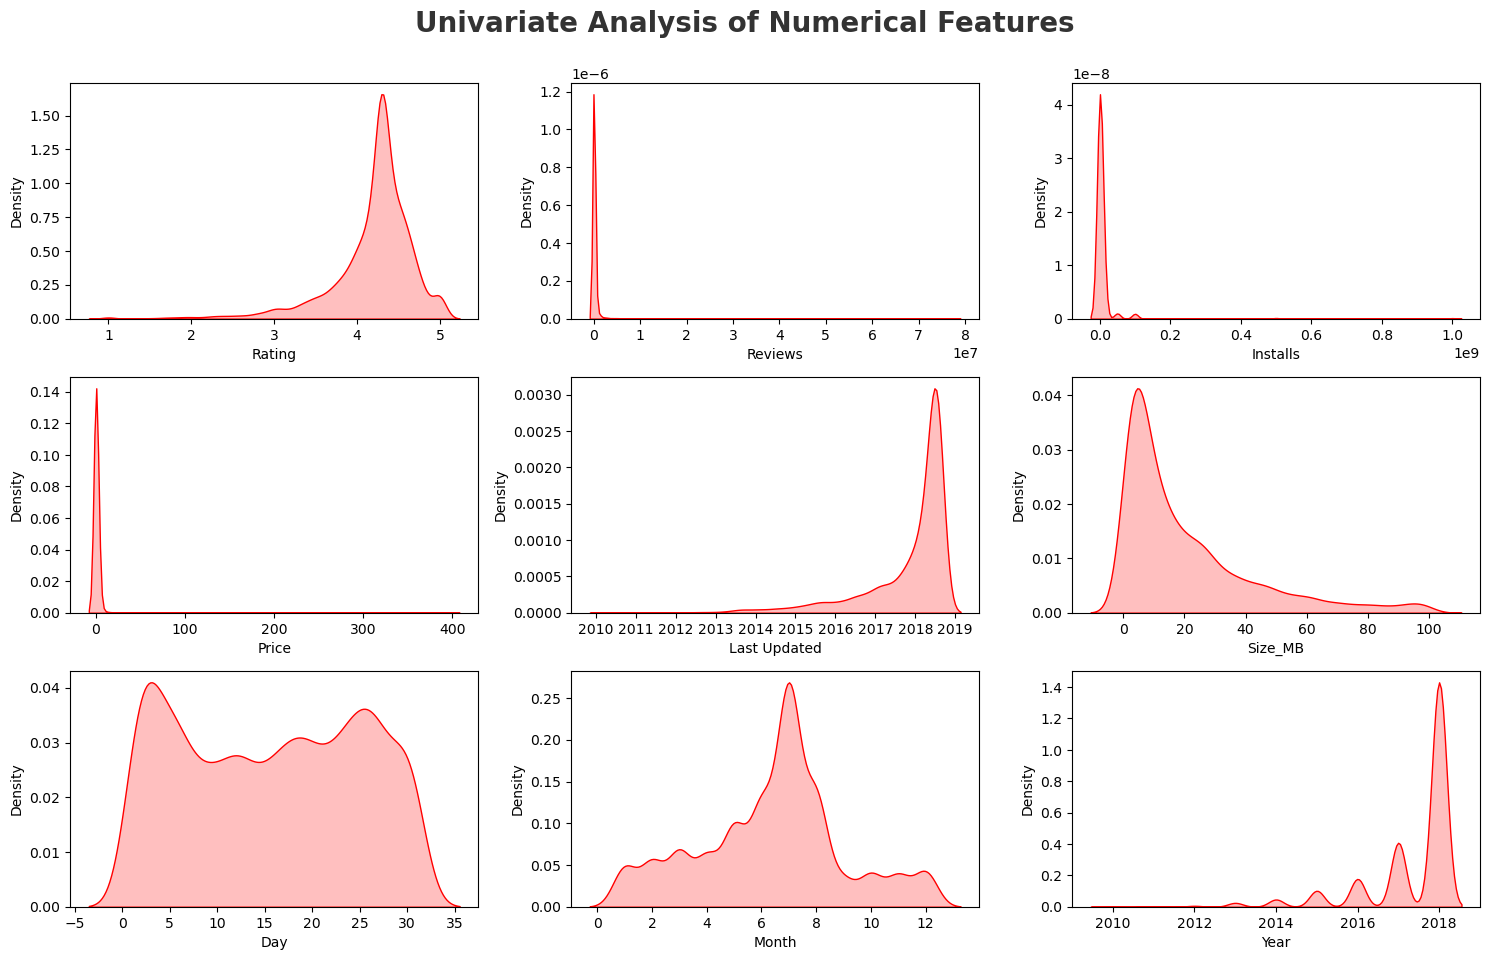

In [39]:
## Proportion of count data on numerical columns
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]],shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

<Axes: ylabel='Type'>

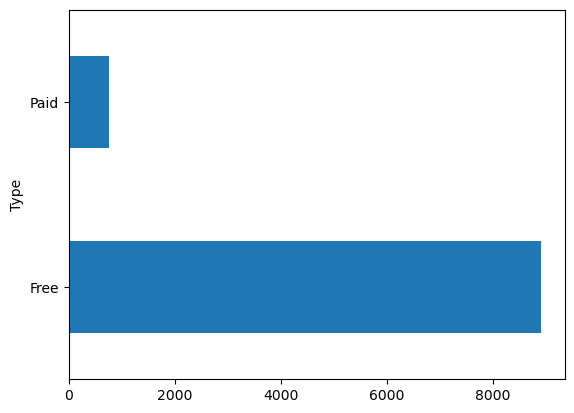

In [40]:
df_copy['Type'].value_counts().plot(kind = 'barh')


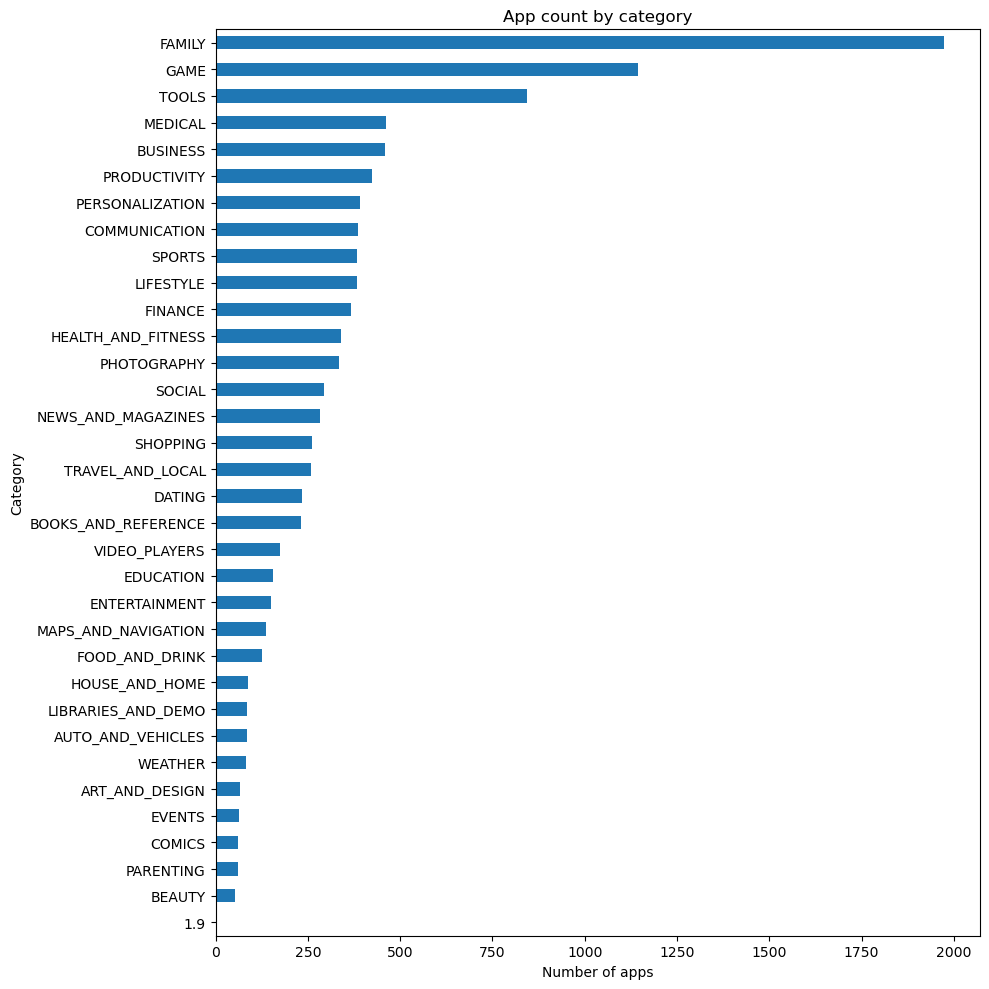

In [75]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(10, 10))
category_counts.sort_values().plot(kind='barh')
plt.xlabel('Number of apps')
plt.title('App count by category')
plt.tight_layout()
plt.show()

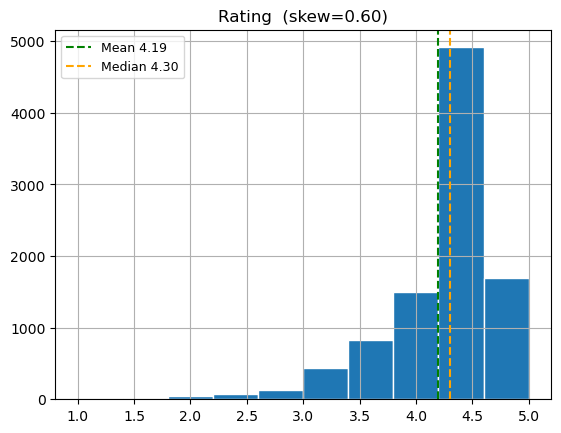

In [43]:
rat_hist = df_copy['Rating'].hist(bins=10, edgecolor='white')
rat_hist.axvline(df['Rating'].mean(),   color='green',  linestyle='--', label=f"Mean {df['Rating'].mean():.2f}")
rat_hist.axvline(df['Rating'].median(), color='orange', linestyle='--', label=f"Median {df['Rating'].median():.2f}")
rat_hist.set_title(f"Rating  (skew={df['Rating'].skew():.2f})")
rat_hist.legend(fontsize=9)

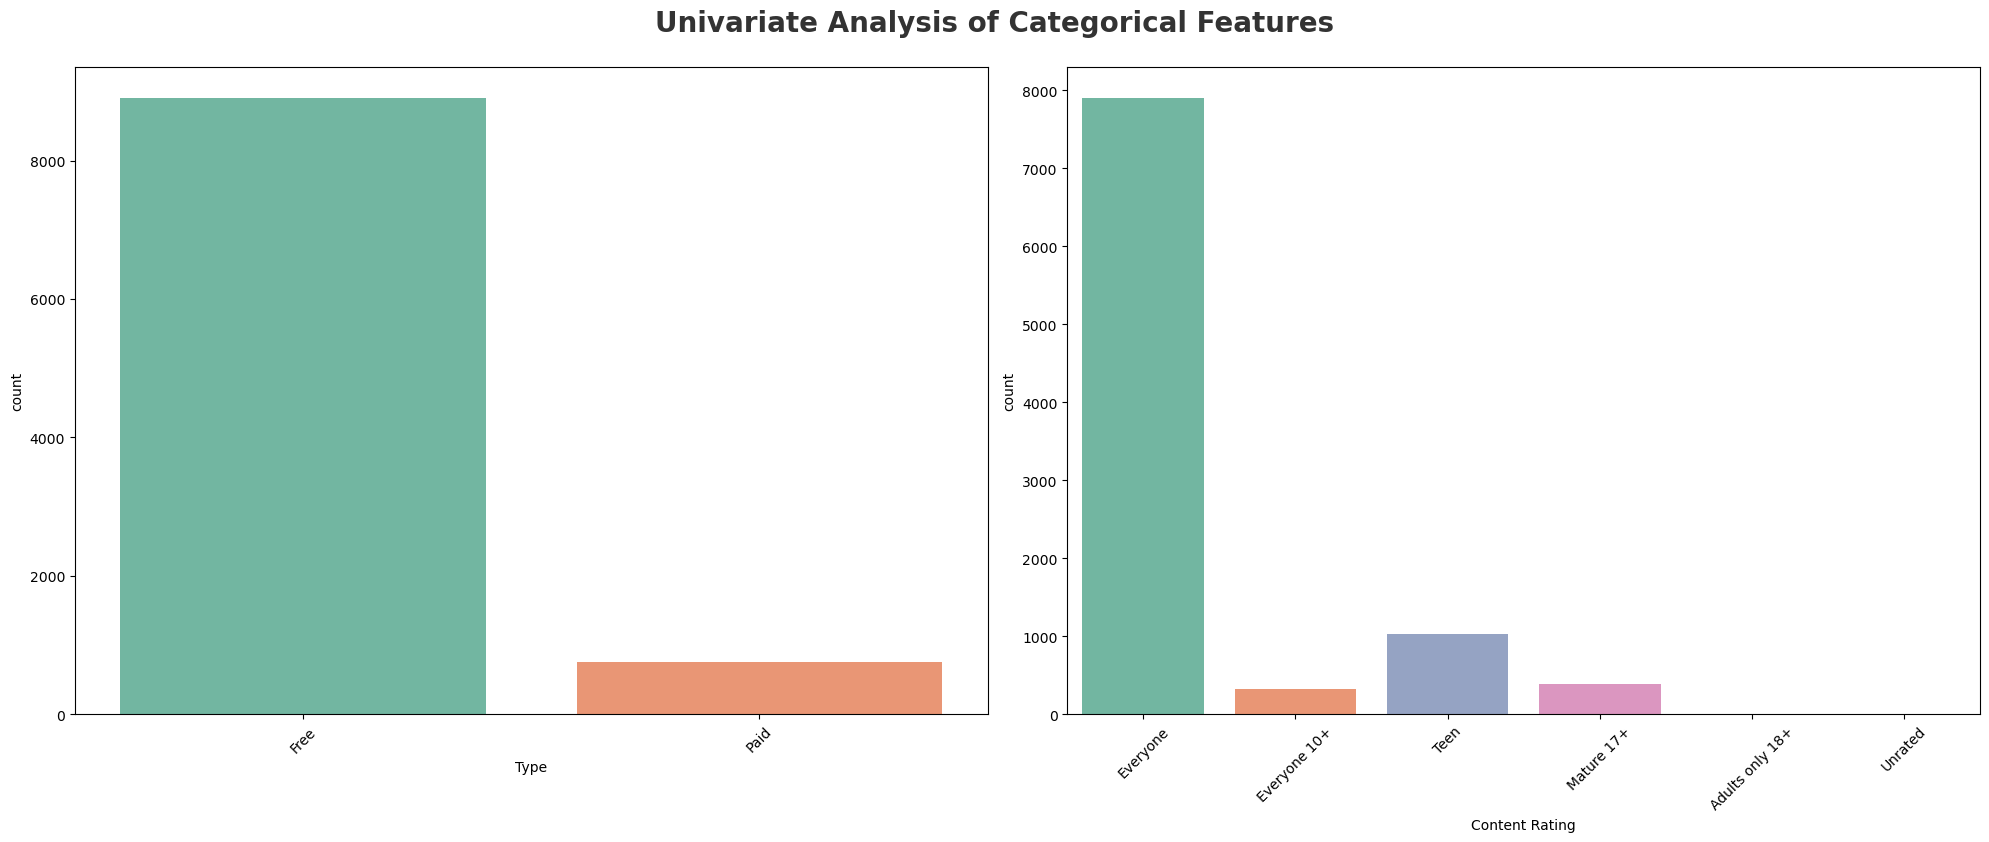

In [41]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = [ 'Type', 'Content Rating']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df_copy[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout() 

<Axes: ylabel='count'>

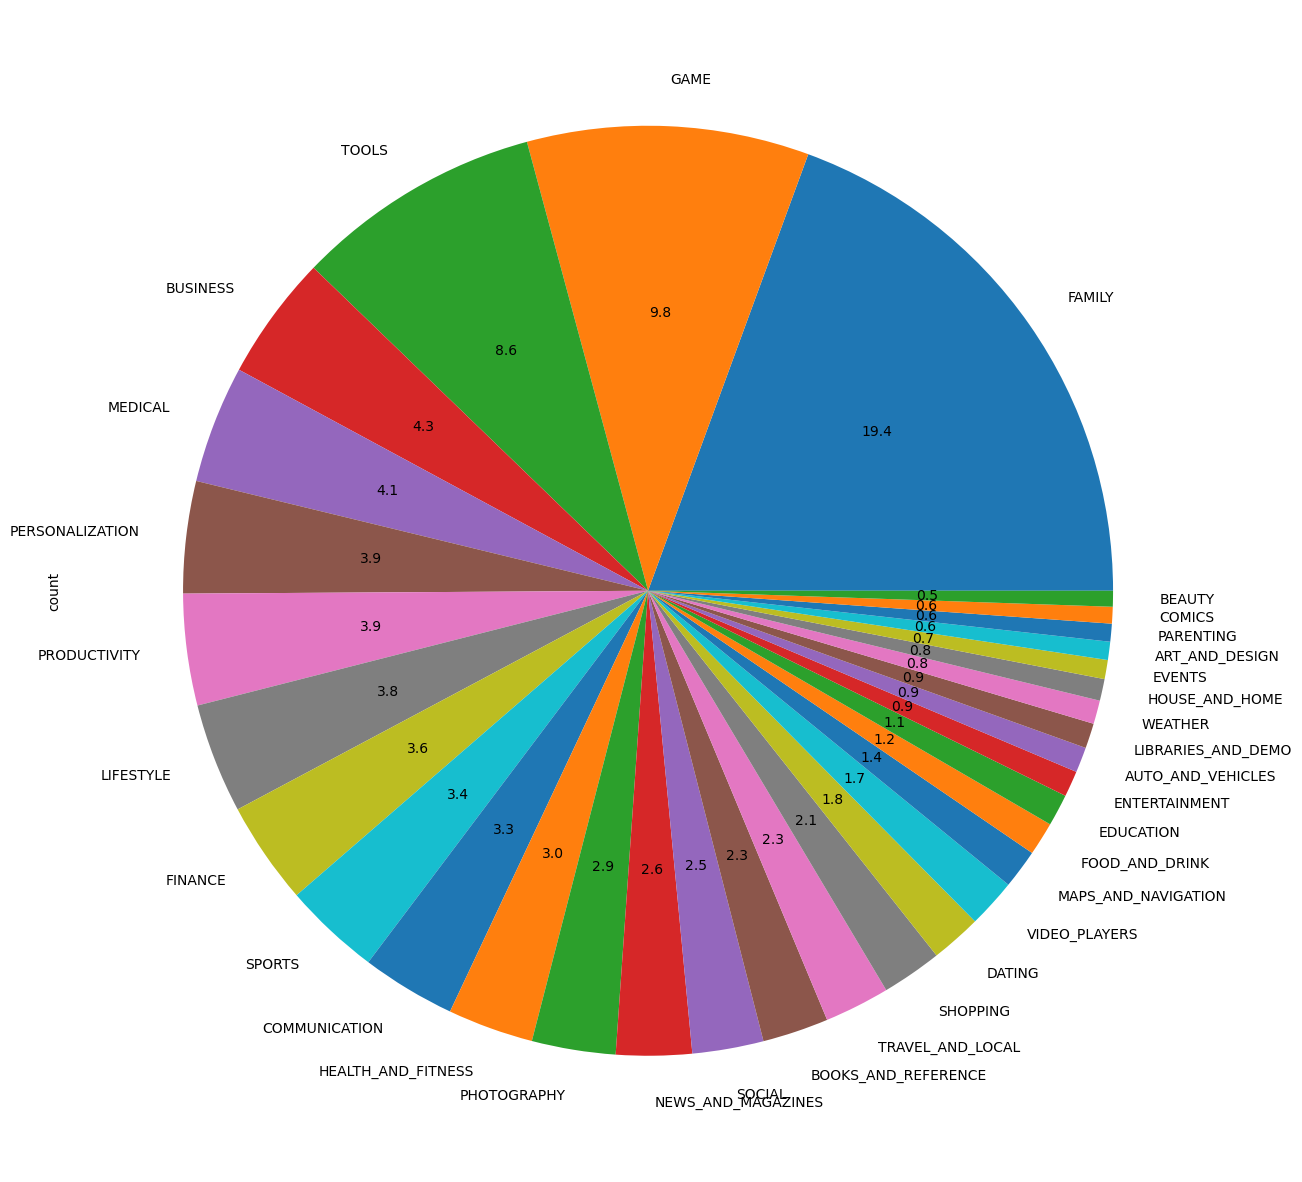

In [44]:
df_copy['Category'].value_counts().plot.pie(y=df_copy['Category'],figsize=(15,16),autopct='%1.1f')

In [45]:
# Log transform skewed columns first
df_copy['Reviews_log']  = np.log1p(df_copy['Reviews'])
df_copy['Installs_log'] = np.log1p(df_copy['Installs'])

log_cols = ['Rating', 'Reviews_log', 'Installs_log', 'Price', 'Size_MB']

corr = df_copy[log_cols].corr()



<Axes: >

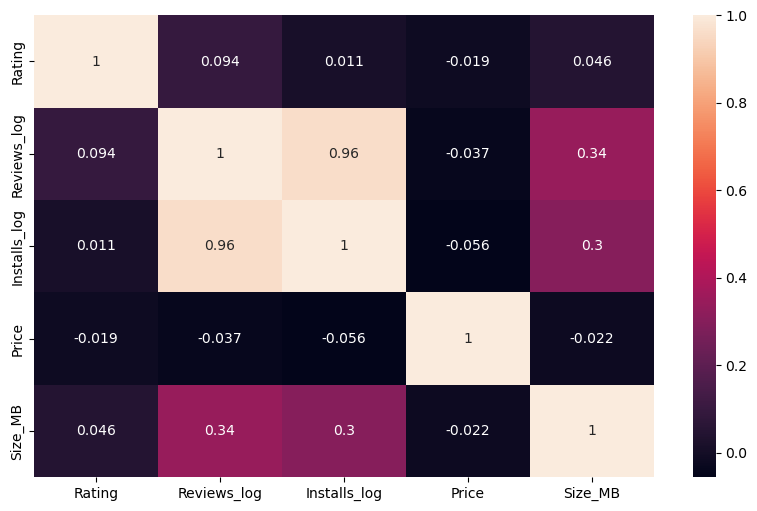

In [47]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True)

# Observations

In [56]:
## Top 10 App Categories
category = pd.DataFrame(df_copy['Category'].value_counts())        #Dataframe of apps on the basis of category
category.rename(columns = {'Category':'Count'},inplace=True)
category.head(10)

,count
Category,
FAMILY,1874
GAME,946
TOOLS,829
BUSINESS,419
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


In [ ]:
# How many apps are there on Google Play Store which get 5 ratings??
rating = df_copy.groupby(['Category','Installs', 'App'])['Rating'].sum().sort_values(ascending = False).reset_index()

toprating_apps = rating[rating.Rating == 5.0]
print("Number of 5 rated apps",toprating_apps.shape[0])
toprating_apps.head(1)

Number of 5 rated apps 271


,Category,Installs,App,Rating
0,PHOTOGRAPHY,100,AJ Cam,5.0000


In [ ]:
# Result
# - There are 271 five rated apps on Google Play store
# - Top most is 'AJ Cam' from 'PHOTOGRAPHY' Category 

Text(0.5, 1.0, 'Most Popular Categories in Play Store')

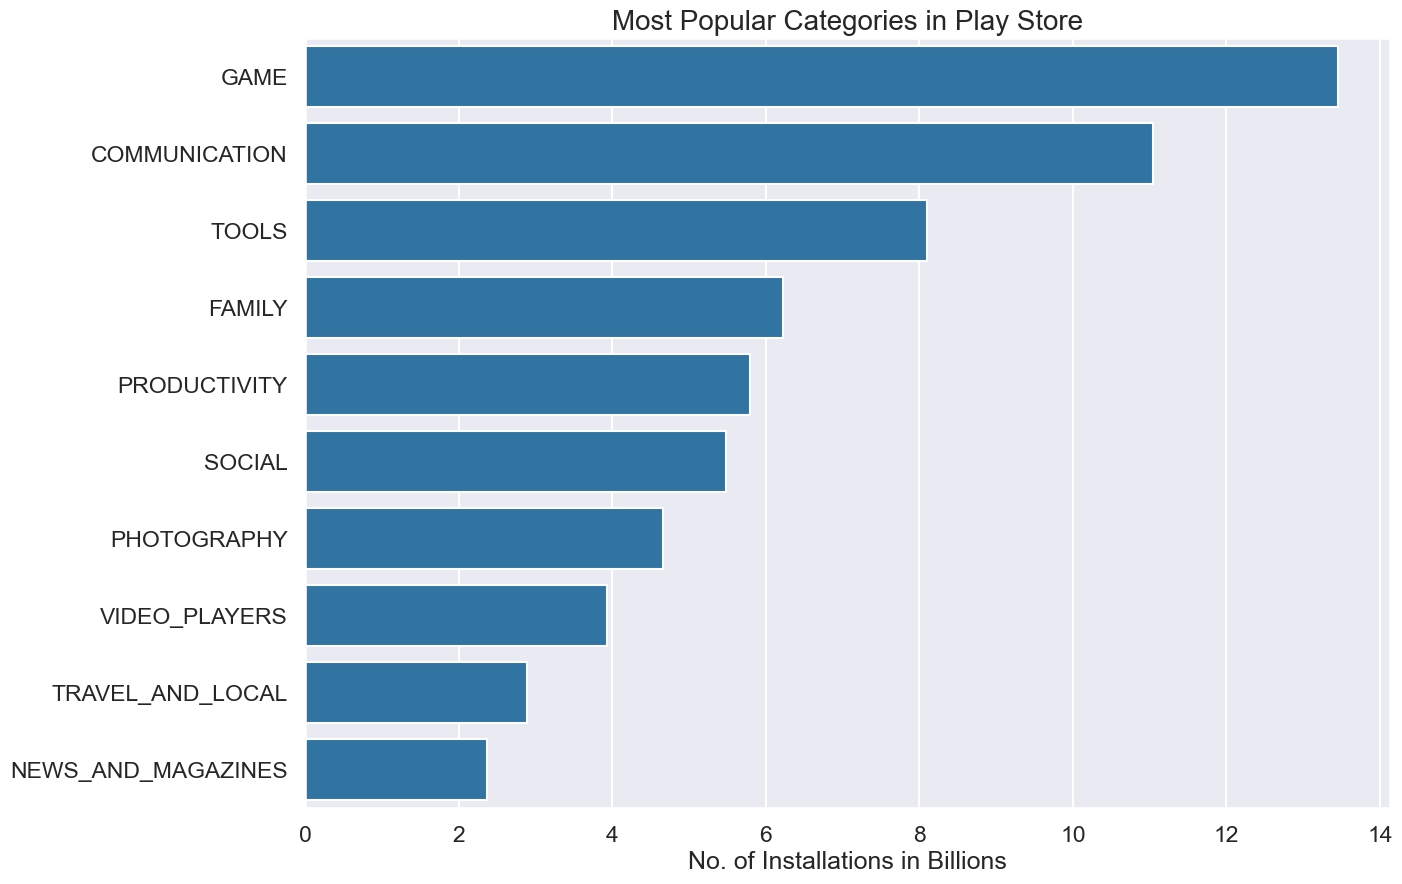

In [69]:
# Category having largest number of installations

df_cat_installs = df_copy.groupby(['Category'])['Installs'].sum().sort_values(ascending = False).reset_index()
df_cat_installs.Installs = df_cat_installs.Installs/1000000000# converting into billions
df2 = df_cat_installs.head(10)
plt.figure(figsize = (14,10))
sns.set_context("talk")
sns.set_style("darkgrid")

ax = sns.barplot(x = 'Installs' , y = 'Category' , data = df2 )
ax.set_xlabel('No. of Installations in Billions')
ax.set_ylabel('')
ax.set_title("Most Popular Categories in Play Store", size = 20)

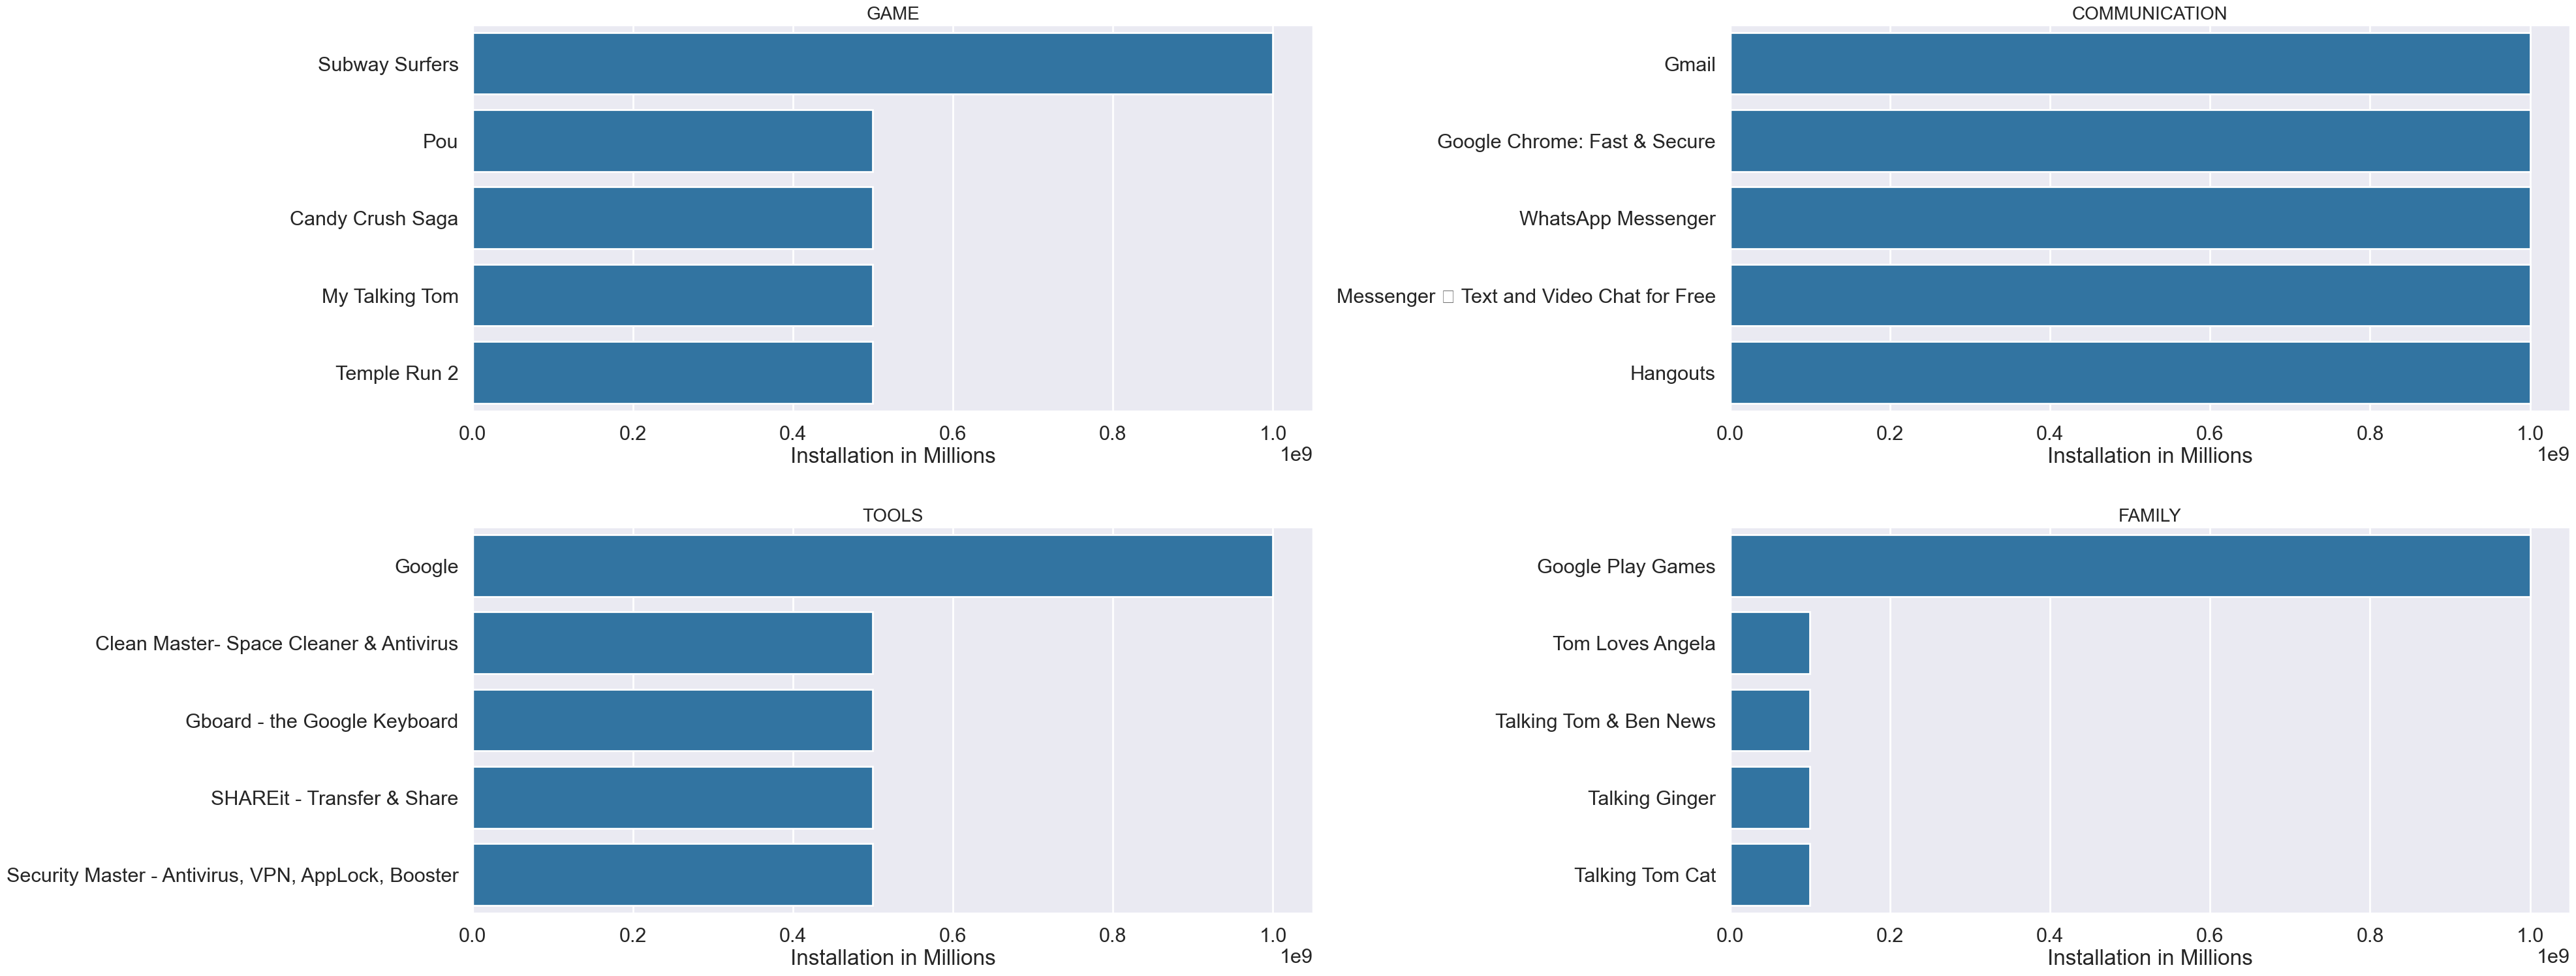

In [73]:
# the Top 5 most installed Apps in Each popular Categories ??

dfa = df_copy.groupby(['Category' ,'App'])['Installs'].sum().reset_index()
dfa = dfa.sort_values('Installs', ascending = False)
apps = ['GAME', 'COMMUNICATION', 'TOOLS', 'FAMILY' ]
sns.set_context("poster")
sns.set_style("darkgrid")

plt.figure(figsize=(40,30))

for i,app in enumerate(apps):
    df2 = dfa[dfa.Category == app]
    df3 = df2.head(5)
    plt.subplot(4,2,i+1)
    sns.barplot(data= df3,x= 'Installs' ,y='App' )
    plt.xlabel('Installation in Millions')
    plt.ylabel('')
    plt.title(app,size = 20)
    
plt.tight_layout()
plt.subplots_adjust(hspace= .3)
plt.show()